In [43]:
# Cell 1 — Imports

from pathlib import Path
import os
import sys
import subprocess
import copy
import math
import zipfile
from urllib.request import urlretrieve

import yaml
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box

In [44]:
# Cell 2 — Paths

PROJECT_ROOT = Path.cwd().parent
BASE_CONFIG = PROJECT_ROOT / "config.yaml"
RUN_CONFIG = PROJECT_ROOT / "config.run.yaml"

print("Project root:", PROJECT_ROOT)
print("Base config:", BASE_CONFIG)
print("Run config:", RUN_CONFIG)

Project root: /Users/pb/Work/OSU/CapstoneProject/bycatch-riskscape
Base config: /Users/pb/Work/OSU/CapstoneProject/bycatch-riskscape/config.yaml
Run config: /Users/pb/Work/OSU/CapstoneProject/bycatch-riskscape/config.run.yaml


In [45]:
# Cell 3
with open(BASE_CONFIG, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

# cfg

In [46]:
# Cell 4 — Edit run config

run_cfg = copy.deepcopy(cfg)

# Region
run_cfg["region"]["name"] = "falkland_islands"
run_cfg["region"]["bbox"]["xmin"] = -64
run_cfg["region"]["bbox"]["ymin"] = -57
run_cfg["region"]["bbox"]["xmax"] = -51
run_cfg["region"]["bbox"]["ymax"] = -47
run_cfg["region"]["buffer_km"] = 50

# Grid
run_cfg["grid"]["resolution"] = 6

# Time
run_cfg["time"]["start"] = "2014-01-01"
run_cfg["time"]["end"] = "2023-12-31"

# run_cfg

In [47]:
# Cell 5

with open(RUN_CONFIG, "w", encoding="utf-8") as f:
    yaml.safe_dump(run_cfg, f, sort_keys=False, allow_unicode=False)

print(f"Wrote run config: {RUN_CONFIG}")

Wrote run config: /Users/pb/Work/OSU/CapstoneProject/bycatch-riskscape/config.run.yaml


In [48]:
# Cell 6

RUN = {
    "grid": True,
    "downloads": False,
    "preprocessing": False,
    "dataset": False,
    "model": False,
    "validation": False,
}

print("Execution plan:")
for stage, flag in RUN.items():
    state = "ON" if flag else "OFF"
    print(f"  {stage}: {state}")

Execution plan:
  grid: ON
  downloads: OFF
  preprocessing: OFF
  dataset: OFF
  model: OFF
  validation: OFF


In [49]:
# Cell 7 — Run helper

import sys

def run_script(script_name):
    """Run a script using config.run.yaml."""
    env = os.environ.copy()
    env["RISKCAPE_CONFIG"] = RUN_CONFIG.name

    result = subprocess.run(
        [sys.executable, f"scripts/{script_name}"],
        check=False,
        env=env,
        cwd=PROJECT_ROOT,
        capture_output=True,
        text=True,
    )

    if result.stdout:
        print(result.stdout)

    if result.stderr:
        print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError(
            f"{script_name} failed with exit code {result.returncode}"
        )
    
# --- Stage runner ---

def run_stage(stage_name, script_name, label=None):
    """Run one pipeline stage if enabled."""
    label = label or stage_name

    if not RUN[stage_name]:
        print(f"{label}: skipped")
        return

    print(f"{label}: running...")
    run_script(script_name)
    print(f"{label}: complete")

In [50]:
# Run Grid stage

run_stage("grid", "build_grid.py", label="Grid")

Grid: running...
INFO     Grid saved: /Users/pb/Work/OSU/CapstoneProject/bycatch-riskscape/data/grids/h3_res6_falkland_islands.geojson
INFO     Grid saved: /Users/pb/Work/OSU/CapstoneProject/bycatch-riskscape/data/grids/h3_res6_falkland_islands.parquet
INFO     Grid saved: /Users/pb/Work/OSU/CapstoneProject/bycatch-riskscape/data/grids/h3_res6_falkland_islands.gpkg
INFO     Hex cells: 37209

Grid: complete


In [51]:
# Cell 9 — Load grid

import pandas as pd

grid_dir = (PROJECT_ROOT / run_cfg["paths"]["grids"]).resolve()

grid_file = next(grid_dir.glob("*.parquet"))

df = pd.read_parquet(grid_file)

print("Grid file:", grid_file.name)
print("Columns:", list(df.columns))

df.head()

Grid file: h3_res6_falkland_islands.parquet
Columns: ['h3_index', 'lat', 'lon', 'geometry']


,h3_index,lat,lon,geometry
0,86df5264fffffff,-55.737142,-59.320971,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x07\x00...
1,86de64037ffffff,-51.712367,-63.354056,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x07\x00...
2,86de2c49fffffff,-55.398613,-57.658710,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x07\x00...
3,86de56997ffffff,-51.329172,-54.218699,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x07\x00...
4,86de72ce7ffffff,-52.106154,-56.368908,b'\x01\x03\x00\x00\x00\x01\x00\x00\x00\x07\x00...


In [52]:
# Cell 10 — Grid checks

required = {"h3_index", "lon", "lat"}
missing = required - set(df.columns)

if missing:
    raise ValueError(f"Grid schema invalid, missing: {missing}")

lon = df["lon"]
lat = df["lat"]

print("Row count:", len(df))
print("Unique ids:", df["h3_index"].nunique())
print("All rows unique by id:", len(df) == df["h3_index"].nunique())

print("Extent:")
print(f"  xmin: {lon.min()}")
print(f"  xmax: {lon.max()}")
print(f"  ymin: {lat.min()}")
print(f"  ymax: {lat.max()}")

Row count: 37209
Unique ids: 37209
All rows unique by id: True
Extent:
  xmin: -64.73146023886804
  xmax: -50.27152104567094
  ymin: -57.45007038413523
  ymax: -46.5495958408838


Text(0.5, 1.0, 'H3 Grid + BBOX')

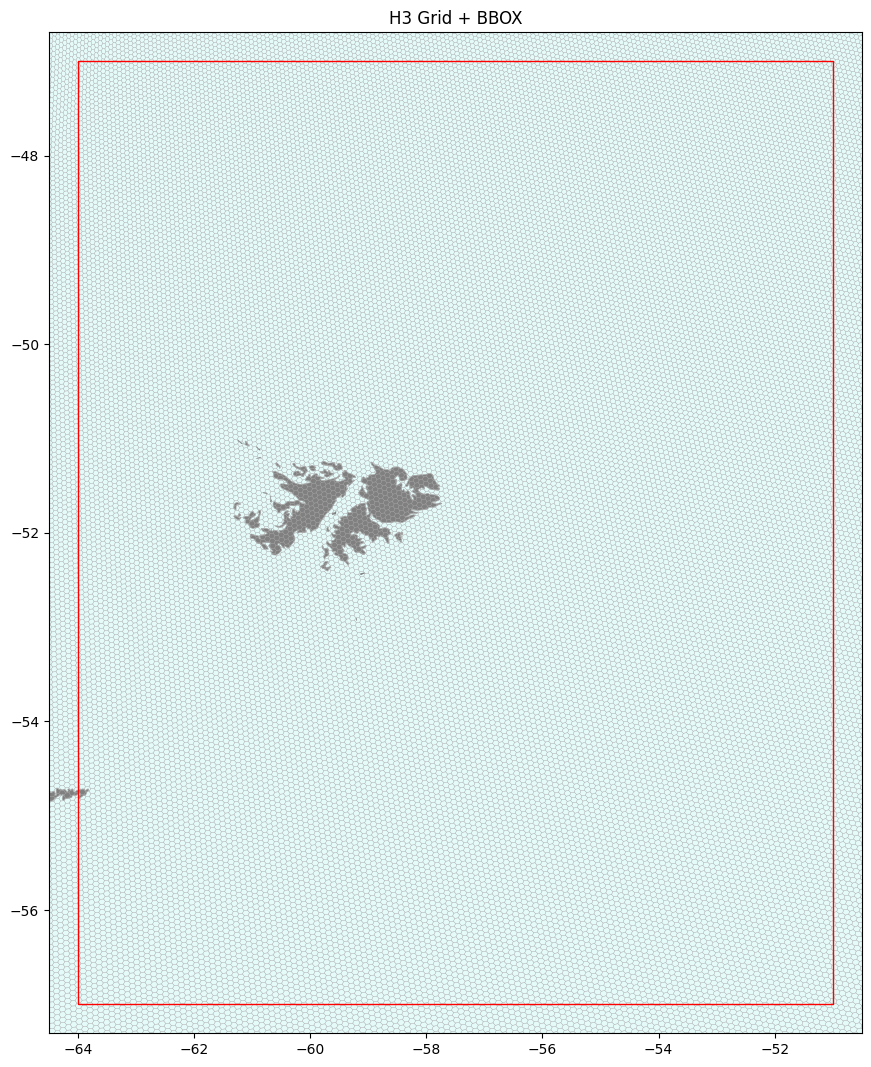

In [53]:
# Cell 12 (refined)

import h3
import geopandas as gpd
from shapely.geometry import Point, Polygon, box

# --- Grid --------------------------------------------------------------------

def h3_to_polygon(h):
    """Convert H3 cell to shapely polygon."""
    boundary = h3.cell_to_boundary(h)  # returns [(lat, lon), ...]
    return Polygon([(lng, lat) for lat, lng in boundary])

gdf = gpd.GeoDataFrame(
    df,
    geometry=df["h3_index"].apply(h3_to_polygon),
    # geometry=[Point(xy) for xy in zip(lon, lat)],
    crs="EPSG:4326",
)

# --- BBOX --------------------------------------------------------------------

bbox = run_cfg["region"]["bbox"]

xmin = bbox["xmin"]
ymin = bbox["ymin"]
xmax = bbox["xmax"]
ymax = bbox["ymax"]

bbox_poly = box(xmin, ymin, xmax, ymax)
bbox_gdf = gpd.GeoDataFrame(geometry=[bbox_poly], crs="EPSG:4326")

# --- Load reference layers ---------------------------------------------------

land = gpd.read_file(PROJECT_ROOT / run_cfg["references"]["land"])
coast = gpd.read_file(PROJECT_ROOT / run_cfg["references"]["coastline"])

# --- Plot --------------------------------------------------------------------

ax = land.plot(color="grey", edgecolor="none", figsize=(13, 13))

ax.set_facecolor("#e5fbfa")

coast.plot(ax=ax, color="darkgrey", linewidth=0.5)

gdf.plot(ax=ax, edgecolor="darkgrey", facecolor="none", linewidth=0.2)
# gdf.plot(ax=ax, markersize=0.1, color="darkgrey")

bbox_gdf.boundary.plot(ax=ax, edgecolor="red", linewidth=1)

mid_lat = (ymin + ymax) / 2
scale = math.cos(math.radians(mid_lat))
margin = 0.5
ax.set_xlim(xmin - margin, xmax + margin)
ax.set_ylim(ymin - margin * scale, ymax + margin * scale)

ax.set_title("H3 Grid + BBOX")